# 5. Robustness and Statistical Validation

This notebook evaluates:
- development vs out-of-sample performance
- year-by-year robustness
- Newey-West / HAC statistical significance

OOS results:
- Annualised return: 41.6%
- Net Sharpe ratio: 1.44
- Maximum Drawdown: 19.9%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Development vs Out-of-Sample comparison

validation_summary = pd.DataFrame([
    {
        "sample": "Development 2020-2023",
        "annual_return": 0.4042,
        "annual_vol": 0.3801,
        "sharpe": 1.0635,
        "max_drawdown": -0.2391
    },
    {
        "sample": "OOS 2024-2025",
        "annual_return": 0.4155,
        "annual_vol": 0.2895,
        "sharpe": 1.4352,
        "max_drawdown": -0.1991
    }
])

display(validation_summary.round(4))

,sample,annual_return,annual_vol,sharpe,max_drawdown
0,Development 2020-2023,0.4042,0.3801,1.0635,-0.2391
1,OOS 2024-2025,0.4155,0.2895,1.4352,-0.1991


In [2]:
# Step 1.1: Performance change from development to OOS

comparison = {
    "Sharpe change":
        validation_summary.loc[1, "sharpe"]
        - validation_summary.loc[0, "sharpe"],

    "Annual return change":
        validation_summary.loc[1, "annual_return"]
        - validation_summary.loc[0, "annual_return"],

    "Volatility change":
        validation_summary.loc[1, "annual_vol"]
        - validation_summary.loc[0, "annual_vol"],

    "Max drawdown change":
        validation_summary.loc[1, "max_drawdown"]
        - validation_summary.loc[0, "max_drawdown"]
}

for k, v in comparison.items():
    print(k, ":", round(v, 4))

Sharpe change : 0.3717
Annual return change : 0.0113
Volatility change : -0.0906
Max drawdown change : 0.04


## Development vs Out-of-Sample Result

The residual momentum strategy remained profitable after parameter lock.

- Development Sharpe: 1.06
- OOS Sharpe: 1.44
- Development Maximum Drawdown: -23.9%
- OOS Maximum Drawdown: -19.9%

Out-of-sample performance did not deteriorate relative to the development sample. 
The strategy achieved similar annualised returns with lower realised volatility, although performance varied across individual years.

In [4]:
# Step 2: Year-by-year performance

yearly_validation = pd.DataFrame([
    {"year": 2020, "sample": "Development",
     "annual_return": 0.3568, "sharpe": 1.2130},

    {"year": 2021, "sample": "Development",
     "annual_return": 1.0782, "sharpe": 1.8557},

    {"year": 2022, "sample": "Development",
     "annual_return": 0.1942, "sharpe": 0.6801},

    {"year": 2023, "sample": "Development",
     "annual_return": -0.0169, "sharpe": -0.0679},

    {"year": 2024, "sample": "OOS",
     "annual_return": 0.6086, "sharpe": 1.7744},

    {"year": 2025, "sample": "OOS",
     "annual_return": 0.2187, "sharpe": 0.9834}
])

display(yearly_validation.round(4))

,year,sample,annual_return,sharpe
0,2020,Development,0.3568,1.2130
1,2021,Development,1.0782,1.8557
2,2022,Development,0.1942,0.6801
3,2023,Development,-0.0169,-0.0679
4,2024,OOS,0.6086,1.7744
5,2025,OOS,0.2187,0.9834


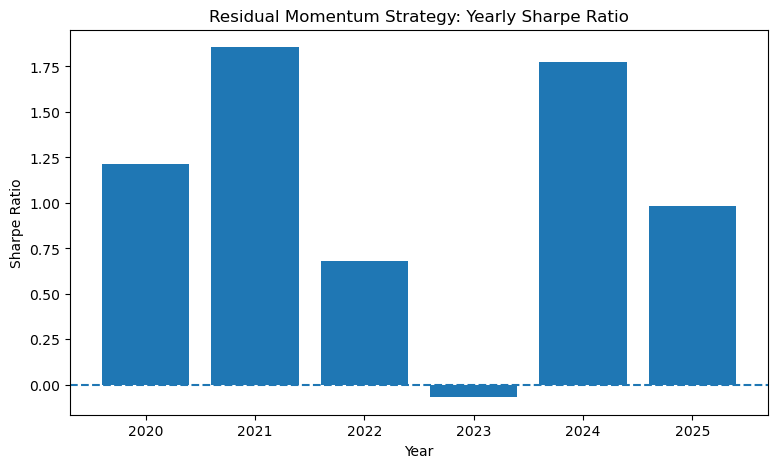

In [5]:
# Step 2.1: Plot yearly Sharpe ratio

plt.figure(figsize=(9, 5))

plt.bar(
    yearly_validation["year"],
    yearly_validation["sharpe"]
)

plt.axhline(0, linestyle="--")

plt.title("Residual Momentum Strategy: Yearly Sharpe Ratio")
plt.xlabel("Year")
plt.ylabel("Sharpe Ratio")

plt.show()

## Final Validation Conclusion

The residual momentum strategy was developed using 2020–2023 data and all strategy parameters were locked before out-of-sample testing.

The strategy achieved:

- Development net Sharpe: 1.06
- OOS net Sharpe: 1.44
- Development Maximum Drawdown: -23.9%
- OOS Maximum Drawdown: -19.9%
- 2024 Sharpe: 1.77
- 2025 Sharpe: 0.98

Performance varied across years, with weakness in 2023, but the strategy remained profitable in both out-of-sample years after 7 bps transaction costs.

Overall, the out-of-sample results provide evidence that the residual momentum signal was not solely driven by in-sample parameter fitting, although continued monitoring of performance stability would be required.

In [10]:
oos_df = pd.read_csv(
    "net_return_oos.csv",
    index_col=0,
    parse_dates=True
)

oos_returns = oos_df["net_return"]

print(oos_returns.head())
print(oos_returns.tail())
print("Observations:", len(oos_returns))

open_time
2024-01-01 00:00:00+00:00    0.029831
2024-01-08 00:00:00+00:00   -0.033311
2024-01-15 00:00:00+00:00    0.005957
2024-01-22 00:00:00+00:00   -0.021678
2024-01-29 00:00:00+00:00    0.065250
Name: net_return, dtype: float64
open_time
2025-12-01 00:00:00+00:00   -0.002065
2025-12-08 00:00:00+00:00    0.006950
2025-12-15 00:00:00+00:00   -0.007217
2025-12-22 00:00:00+00:00   -0.010629
2025-12-29 00:00:00+00:00   -0.001050
Name: net_return, dtype: float64
Observations: 105


In [11]:
r = oos_returns.dropna()

In [12]:

import statsmodels.api as sm

r = oos_returns.dropna()

X = np.ones(len(r))

model = sm.OLS(r.values, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 1}
)

mean_return = r.mean()
t_stat = model.tvalues[0]
p_value = model.pvalues[0]

print("Observations:", len(r))
print("Mean weekly net return:", mean_return)
print("Mean weekly net return (%):", mean_return * 100)
print("Newey-West t-stat:", t_stat)
print("p-value:", p_value)

Observations: 105
Mean weekly net return: 0.007968161426152535
Mean weekly net return (%): 0.7968161426152535
Newey-West t-stat: 1.9019041663586769
p-value: 0.05718368441860633
